In [1]:
import pandas as pd 
import numpy as np
from IPython.display import display
from scipy.signal import welch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('VMD_EO', encoding='cp1251', sep='\s{2,}', engine='python') # загружаем датасетd
df.head(2)

,%1.Cтабилографический сигнал X,2.Cтабилографический сигнал Y,3.Баллистограмма,4.Дыхание 1
0,1.648438,5.609375,71.638000,49.992981
1,1.757812,5.773438,71.683014,49.992981


In [ ]:
df.info()
df.head(2)
print('index object:', df.index, '\n\ncolumns object:', df.columns, '\n\ndataframe shape:', df.shape) #узнаем типы данных

In [3]:
# Переименование столбцов согласно файлу
df.columns = ['Stabilograph_X', 'Stabilograph_Y', 'Ballistogram', 'Breathing']

In [4]:
# 2. Статистические параметры
sigma_x = np.std(df['Stabilograph_X'])
sigma_y = np.std(df['Stabilograph_Y'])

print(f'sigma_x = {sigma_x}')
print(f'sigma_y = {sigma_y}')

sigma_x = 1.441318454861604
sigma_y = 3.225077326811541


In [5]:
# Вычисление ковариационной матрицы
Cov = np.cov(df['Stabilograph_X'], df['Stabilograph_Y'])
S = 2 * np.log(1/0.1) * np.sqrt(Cov[0, 0] * Cov[1, 1] - Cov[0, 1]**2)
print(f'S_el = {S}')

S_el = 20.334266962400715


In [6]:
# 2. Параметры для Welch
fs = 50  # частота дискретизации
window = 'hann'  # окно Ханна
nperseg = 1024  # длина сегмента
noverlap = 500  # количество перекрывающихся отсчетов
nfft = 1024  # количество точек для FFT

In [42]:
# Функция для расчета спектра мощности и построения графика
def plot_welch(column, Xmax, Ymax, title):
    f, Pxx = welch(column, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    
    plt.figure()
    plt.semilogy(f, Pxx)
    plt.xlim([0, Xmax])
    plt.ylim([0, Ymax])
    plt.xlabel('Частота [Гц]')
    plt.ylabel('Спектральная плотность мощности [кг^2/Гц]')
    plt.title(title)
    plt.grid()
    plt.show()

In [ ]:
# 3. Построение графиков для разных столбцов
# Для координат центра давления (Stabilograph_X и Stabilograph_Y): Xmax = 2 Гц
plot_welch(df['Stabilograph_X'], Xmax=2, Ymax=None, title='Спектр мощности для Stabilograph_X')
plot_welch(df['Stabilograph_Y'], Xmax=2, Ymax=None, title='Спектр мощности для Stabilograph_Y')

# Для веса (Ballistogram): Xmax = 12 Гц
plot_welch(df['Ballistogram'], Xmax=12, Ymax=None, title='Спектр мощности для Ballistogram')


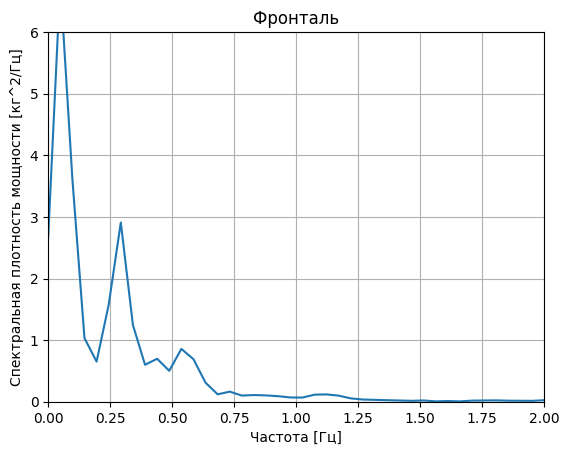

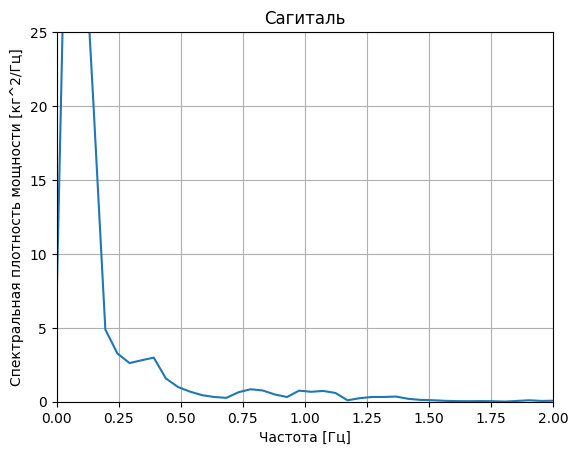

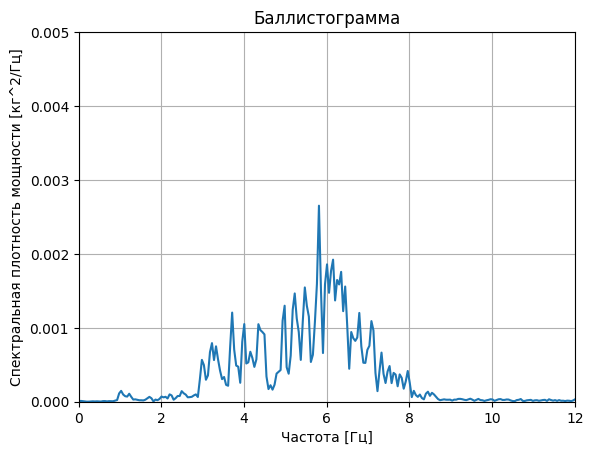

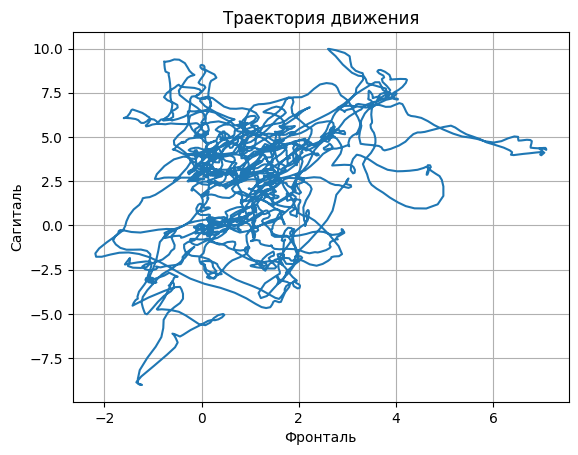

In [7]:
# Расчет спектра мощности
Fx, Pxx = welch(df['Stabilograph_X'], fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
Fy, Pyy = welch(df['Stabilograph_Y'], fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
Fw, P = welch(df['Ballistogram'], fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

# 4. Построение графиков

# Фронтальная ось
plt.figure()
plt.plot(Fx, Pxx)
plt.xlim([0, 2])
plt.ylim([0, 6])
plt.xlabel('Частота [Гц]')
plt.ylabel('Спектральная плотность мощности [кг^2/Гц]')
plt.title('Фронталь')
plt.grid()
plt.show()

# Сагиттальная ось
plt.figure()
plt.plot(Fy, Pyy)
plt.xlim([0, 2])
plt.ylim([0, 25])
plt.xlabel('Частота [Гц]')
plt.ylabel('Спектральная плотность мощности [кг^2/Гц]')
plt.title('Сагиталь')
plt.grid()
plt.show()

# Баллистограмма
plt.figure()
plt.plot(Fw, P)
plt.xlim([0, 12])
plt.ylim([0, 5e-3])
plt.xlabel('Частота [Гц]')
plt.ylabel('Спектральная плотность мощности [кг^2/Гц]')
plt.title('Баллистограмма')
plt.grid()
plt.show()

# 5. Дополнительные графики
# Траектория (фронталь-сагиталь)
plt.figure()
plt.plot(df['Stabilograph_X'], df['Stabilograph_Y'])
plt.xlabel('Фронталь')
plt.ylabel('Сагиталь')
plt.title('Траектория движения')
plt.grid()
plt.show()

# График баллистограммы
# plt.figure()
# plt.plot(df['Ballistogram'])
# plt.xlabel('Время')
# plt.ylabel('Баллистограмма')
# plt.title('График баллистограммы')
# plt.grid()
# plt.show()